# Midterm Project: Image Classification with Machine Learning Pipeline
**Dataset:** EMNIST Letters

**Pipeline:** HOG Feature Extraction + SVM Classifier

## 0. Import Libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
from sklearn.preprocessing import LabelEncoder
from skimage.feature import hog
from skimage import exposure
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## 1. Dataset Preparation

Download EMNIST Letters dari: https://www.kaggle.com/datasets/crawford/emnist/data

File yang dibutuhkan: `emnist-letters-train.csv` dan `emnist-letters-test.csv`

Atau bisa juga menggunakan library `emnist`:
```
pip install emnist
```

In [9]:
# ============================================================
# OPTION A: Load dari CSV (Kaggle)
# ============================================================
train_df = pd.read_csv('../emnist-letters-train.csv', header=None)
test_df  = pd.read_csv('../emnist-letters-test.csv',  header=None)

# Gabungkan train + test dulu, baru kita re-split sesuai instruksi
df = pd.concat([train_df, test_df], ignore_index=True)
labels_all = df.iloc[:, 0].values        # kolom pertama = label (1-26)
pixels_all = df.iloc[:, 1:].values       # 784 kolom pixel

print(f'Dataset loaded dari CSV')
print(f'Total samples: {len(labels_all)}')
print(f'Classes: {np.unique(labels_all)}')

Dataset loaded dari CSV
Total samples: 103600
Classes: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26]


In [10]:
# ============================================================
# Ambil 2600 samples seimbang (100 per kelas, 26 kelas)
# ============================================================
N_PER_CLASS = 100
N_CLASSES   = 26

np.random.seed(42)  # reproducibility

selected_pixels = []
selected_labels = []

for cls in range(1, N_CLASSES + 1):          # label 1-26
    idx = np.where(labels_all == cls)[0]
    idx_sampled = np.random.choice(idx, N_PER_CLASS, replace=False)
    selected_pixels.append(pixels_all[idx_sampled])
    selected_labels.append(labels_all[idx_sampled])

X = np.concatenate(selected_pixels, axis=0).astype(np.float32)
y = np.concatenate(selected_labels, axis=0)

# Encode label 1-26 -> 0-25
le = LabelEncoder()
y = le.fit_transform(y)

print(f'Total samples dipilih : {X.shape[0]}')
print(f'Jumlah kelas           : {len(np.unique(y))}')
print(f'Shape pixel            : {X.shape}')
print(f'Distribusi kelas       : {np.bincount(y)}')

Total samples dipilih : 2600
Jumlah kelas           : 26
Shape pixel            : (2600, 784)
Distribusi kelas       : [100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100
 100 100 100 100 100 100 100 100]


In [11]:
# ============================================================
# Shuffle Dataset
# ============================================================
shuffle_idx = np.random.permutation(len(X))
X = X[shuffle_idx]
y = y[shuffle_idx]
print('Dataset shuffled!')

Dataset shuffled!


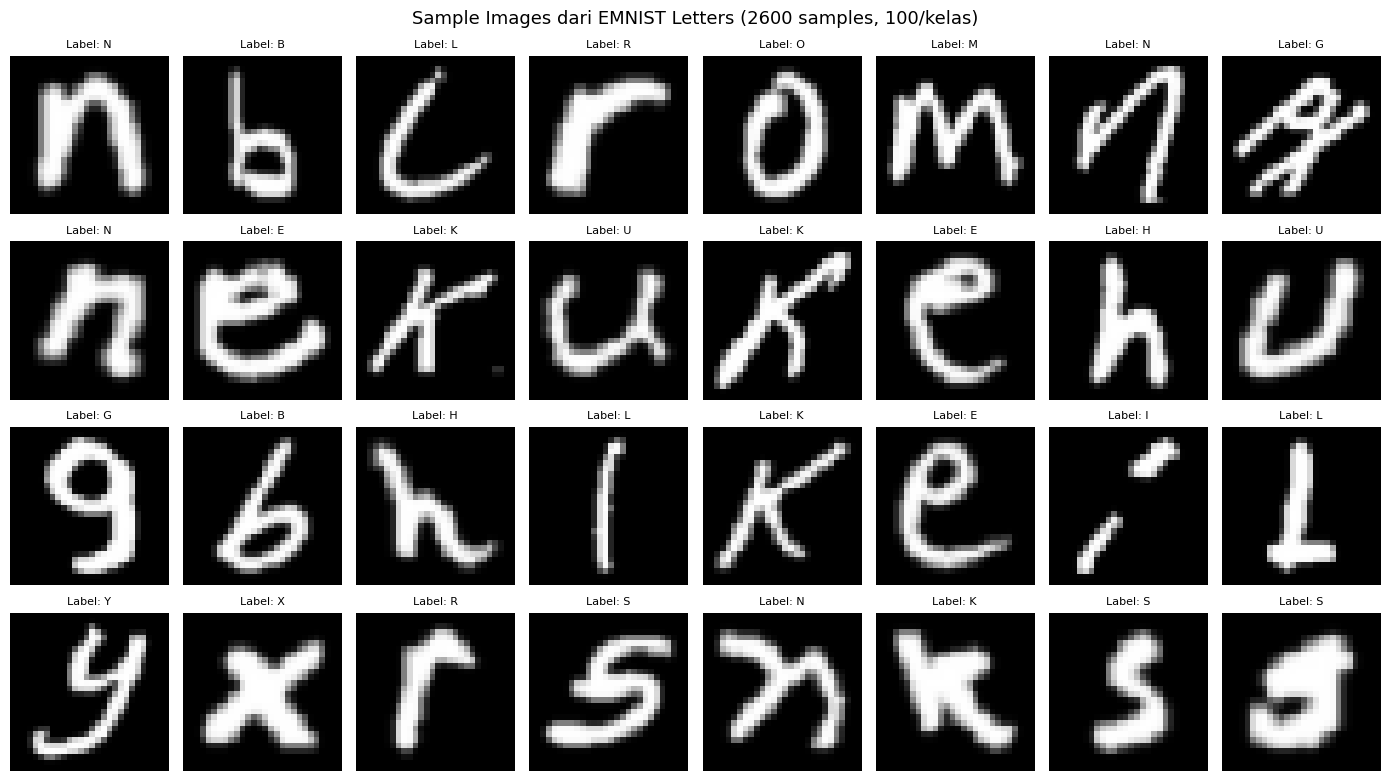

Visualisasi selesai!


In [12]:
# ============================================================
# Visualisasi beberapa sampel
# ============================================================
letter_map = {i: chr(ord('A') + i) for i in range(26)}

fig, axes = plt.subplots(4, 8, figsize=(14, 8))
fig.suptitle('Sample Images dari EMNIST Letters (2600 samples, 100/kelas)', fontsize=13)

for i, ax in enumerate(axes.flat):
    if i < 32:
        img = X[i].reshape(28, 28)
        # EMNIST perlu transpose
        img = np.transpose(img)
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Label: {letter_map[y[i]]}', fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100)
plt.show()
print('Visualisasi selesai!')

In [13]:
# ============================================================
# Split Dataset: 80% Train, 20% Test (Leave One Out style)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set  : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Testing set   : {X_test.shape[0]} samples  ({X_test.shape[0]/len(X)*100:.0f}%)')

Training set  : 2080 samples (80%)
Testing set   : 520 samples  (20%)


## 2. HOG Feature Extraction

In [14]:
# ============================================================
# HOG Parameters (diubah dari default)
# Default skimage: orientations=9, pixels_per_cell=(8,8), cells_per_block=(3,3)
# ============================================================
HOG_PARAMS = {
    'orientations'    : 12,          # default=9  -> ditingkatkan untuk lebih banyak arah
    'pixels_per_cell' : (7, 7),      # default=(8,8) -> lebih kecil, resolusi lebih tinggi
    'cells_per_block' : (2, 2),      # default=(3,3) -> normalisasi lebih lokal
    'block_norm'      : 'L2-Hys',
    'visualize'       : False,
    'transform_sqrt'  : True,        # gamma correction
    'feature_vector'  : True
}

print('HOG Parameters:')
for k, v in HOG_PARAMS.items():
    print(f'  {k:20s}: {v}')

HOG Parameters:
  orientations        : 12
  pixels_per_cell     : (7, 7)
  cells_per_block     : (2, 2)
  block_norm          : L2-Hys
  visualize           : False
  transform_sqrt      : True
  feature_vector      : True


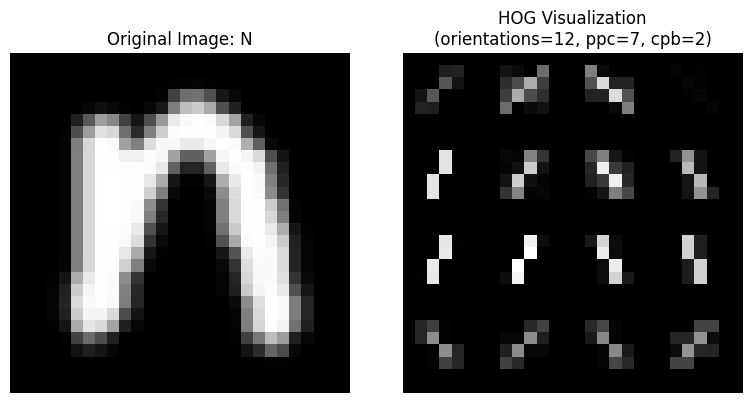

HOG feature vector length: 432


In [15]:
# ============================================================
# Visualisasi HOG pada 1 sampel
# ============================================================
sample_img = np.transpose(X[0].reshape(28, 28))

hog_features, hog_image = hog(
    sample_img,
    orientations=HOG_PARAMS['orientations'],
    pixels_per_cell=HOG_PARAMS['pixels_per_cell'],
    cells_per_block=HOG_PARAMS['cells_per_block'],
    block_norm=HOG_PARAMS['block_norm'],
    transform_sqrt=HOG_PARAMS['transform_sqrt'],
    visualize=True,
    feature_vector=True
)

hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title(f'Original Image: {letter_map[y[0]]}')
axes[0].axis('off')

axes[1].imshow(hog_image_rescaled, cmap='gray')
axes[1].set_title(f'HOG Visualization\n(orientations=12, ppc=7, cpb=2)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('hog_visualization.png', dpi=100)
plt.show()
print(f'HOG feature vector length: {len(hog_features)}')

In [16]:
# ============================================================
# Ekstrak HOG untuk seluruh dataset
# ============================================================
def extract_hog_features(data, params):
    features = []
    for i, row in enumerate(data):
        img = np.transpose(row.reshape(28, 28))
        feat = hog(
            img,
            orientations=params['orientations'],
            pixels_per_cell=params['pixels_per_cell'],
            cells_per_block=params['cells_per_block'],
            block_norm=params['block_norm'],
            transform_sqrt=params['transform_sqrt'],
            visualize=False,
            feature_vector=True
        )
        features.append(feat)
        if (i+1) % 500 == 0:
            print(f'  Processed {i+1}/{len(data)} images...')
    return np.array(features)

print('Mengekstrak HOG features dari training set...')
X_train_hog = extract_hog_features(X_train, HOG_PARAMS)

print('Mengekstrak HOG features dari testing set...')
X_test_hog  = extract_hog_features(X_test,  HOG_PARAMS)

print(f'\nShape HOG Train : {X_train_hog.shape}')
print(f'Shape HOG Test  : {X_test_hog.shape}')

Mengekstrak HOG features dari training set...
  Processed 500/2080 images...
  Processed 1000/2080 images...
  Processed 1500/2080 images...
  Processed 2000/2080 images...
Mengekstrak HOG features dari testing set...
  Processed 500/520 images...

Shape HOG Train : (2080, 432)
Shape HOG Test  : (520, 432)


## 3. Classification dengan SVM + Grid Search

In [17]:
# ============================================================
# Grid Search untuk menemukan parameter SVM terbaik
# ============================================================
param_grid = {
    'kernel': ['rbf', 'poly'],   # kernel type
    'C'     : [1, 10, 100],      # regularization
    'gamma' : ['scale', 'auto']  # kernel coefficient
}

print('Parameter Grid yang akan dicoba:')
for k, v in param_grid.items():
    print(f'  {k}: {v}')

svm = SVC(random_state=42, probability=True)

grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,              # 5-fold cross validation
    scoring='accuracy',
    n_jobs=-1,         # gunakan semua CPU
    verbose=2
)

print('\nMemulai Grid Search... (bisa memakan beberapa menit)')
grid_search.fit(X_train_hog, y_train)

print(f'\nBest Parameters : {grid_search.best_params_}')
print(f'Best CV Score   : {grid_search.best_score_:.4f}')

Parameter Grid yang akan dicoba:
  kernel: ['rbf', 'poly']
  C: [1, 10, 100]
  gamma: ['scale', 'auto']

Memulai Grid Search... (bisa memakan beberapa menit)
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters : {'C': 1, 'gamma': 'scale', 'kernel': 'poly'}
Best CV Score   : 0.8120


In [18]:
# ============================================================
# Tampilkan hasil Grid Search
# ============================================================
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_sorted = cv_results[['param_kernel', 'param_C', 'param_gamma',
                                  'mean_test_score', 'std_test_score', 'rank_test_score']]\
                    .sort_values('rank_test_score')

print('Top 10 kombinasi parameter:')
print(cv_results_sorted.head(10).to_string(index=False))

# Ambil model terbaik
best_svm = grid_search.best_estimator_
print(f'\nModel terbaik: {best_svm}')

Top 10 kombinasi parameter:
param_kernel  param_C param_gamma  mean_test_score  std_test_score  rank_test_score
        poly        1       scale         0.812019        0.014849                1
         rbf       10       scale         0.807212        0.015385                2
         rbf      100       scale         0.806731        0.015020                3
        poly       10       scale         0.805288        0.016304                4
        poly      100       scale         0.805288        0.016304                4
         rbf        1       scale         0.800481        0.016930                6
         rbf      100        auto         0.787981        0.020476                7
         rbf       10        auto         0.724519        0.021747                8
        poly        1        auto         0.657212        0.027559                9
        poly       10        auto         0.657212        0.027559                9

Model terbaik: SVC(C=1, kernel='poly', probabil

In [19]:
# ============================================================
# Training Performance (pada data training)
# ============================================================
y_train_pred = best_svm.predict(X_train_hog)

train_acc  = accuracy_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred, average='macro')
train_rec  = recall_score(y_train, y_train_pred, average='macro')
train_f1   = f1_score(y_train, y_train_pred, average='macro')

print('=' * 45)
print('       TRAINING PERFORMANCE')
print('=' * 45)
print(f'  Accuracy  : {train_acc:.4f}  ({train_acc*100:.2f}%)')
print(f'  Precision : {train_prec:.4f}')
print(f'  Recall    : {train_rec:.4f}')
print(f'  F1-Score  : {train_f1:.4f}')
print('=' * 45)

       TRAINING PERFORMANCE
  Accuracy  : 0.9957  (99.57%)
  Precision : 0.9957
  Recall    : 0.9957
  F1-Score  : 0.9957


## 4. Evaluation

In [20]:
# ============================================================
# Test Performance (pada data testing)
# ============================================================
y_test_pred = best_svm.predict(X_test_hog)

test_acc  = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='macro')
test_rec  = recall_score(y_test, y_test_pred, average='macro')
test_f1   = f1_score(y_test, y_test_pred, average='macro')

print('=' * 45)
print('        TESTING PERFORMANCE')
print('=' * 45)
print(f'  Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  Precision : {test_prec:.4f}')
print(f'  Recall    : {test_rec:.4f}')
print(f'  F1-Score  : {test_f1:.4f}')
print('=' * 45)

        TESTING PERFORMANCE
  Accuracy  : 0.8404  (84.04%)
  Precision : 0.8445
  Recall    : 0.8404
  F1-Score  : 0.8392


   Metric    Train     Test
 Accuracy 0.995673 0.840385
Precision 0.995678 0.844490
   Recall 0.995673 0.840385
 F1-Score 0.995673 0.839171


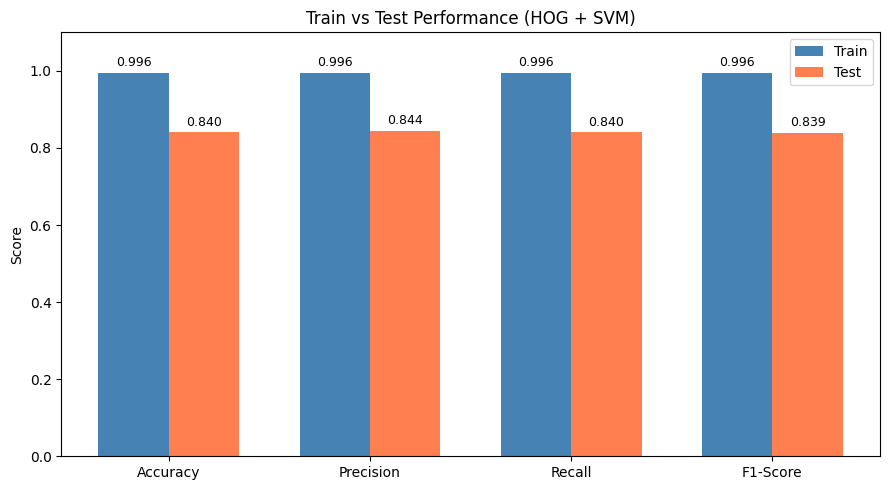

In [21]:
# ============================================================
# Ringkasan perbandingan Train vs Test
# ============================================================
summary = pd.DataFrame({
    'Metric'   : ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Train'    : [train_acc, train_prec, train_rec, train_f1],
    'Test'     : [test_acc,  test_prec,  test_rec,  test_f1]
})

print(summary.to_string(index=False))

# Bar chart
x = np.arange(4)
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, summary['Train'], width, label='Train', color='steelblue')
bars2 = ax.bar(x + width/2, summary['Test'],  width, label='Test',  color='coral')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Train vs Test Performance (HOG + SVM)')
ax.set_xticks(x)
ax.set_xticklabels(summary['Metric'])
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=100)
plt.show()

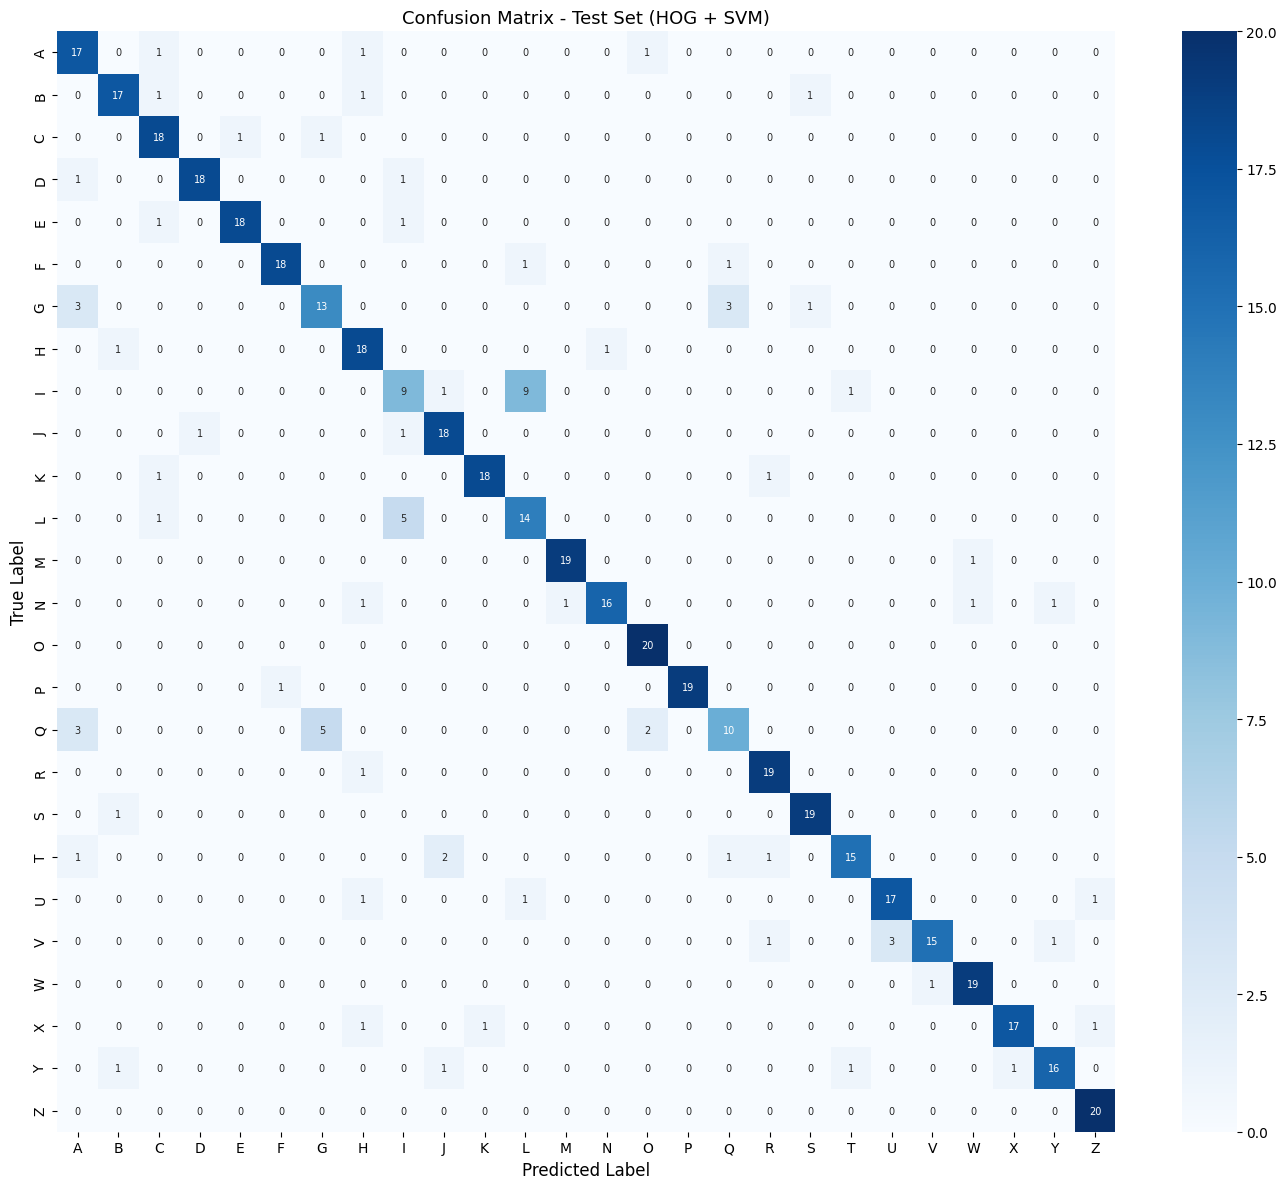

In [22]:
# ============================================================
# Confusion Matrix
# ============================================================
cm = confusion_matrix(y_test, y_test_pred)
labels_str = [letter_map[i] for i in range(26)]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_str, yticklabels=labels_str, ax=ax,
            annot_kws={'size': 7})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - Test Set (HOG + SVM)', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

In [23]:
# ============================================================
# Classification Report per kelas
# ============================================================
report = classification_report(y_test, y_test_pred,
                                target_names=labels_str)
print('Classification Report (Test Set):')
print(report)

Classification Report (Test Set):
              precision    recall  f1-score   support

           A       0.68      0.85      0.76        20
           B       0.85      0.85      0.85        20
           C       0.78      0.90      0.84        20
           D       0.95      0.90      0.92        20
           E       0.95      0.90      0.92        20
           F       0.95      0.90      0.92        20
           G       0.68      0.65      0.67        20
           H       0.75      0.90      0.82        20
           I       0.53      0.45      0.49        20
           J       0.82      0.90      0.86        20
           K       0.95      0.90      0.92        20
           L       0.56      0.70      0.62        20
           M       0.95      0.95      0.95        20
           N       0.94      0.80      0.86        20
           O       0.87      1.00      0.93        20
           P       1.00      0.95      0.97        20
           Q       0.67      0.50      0.57    

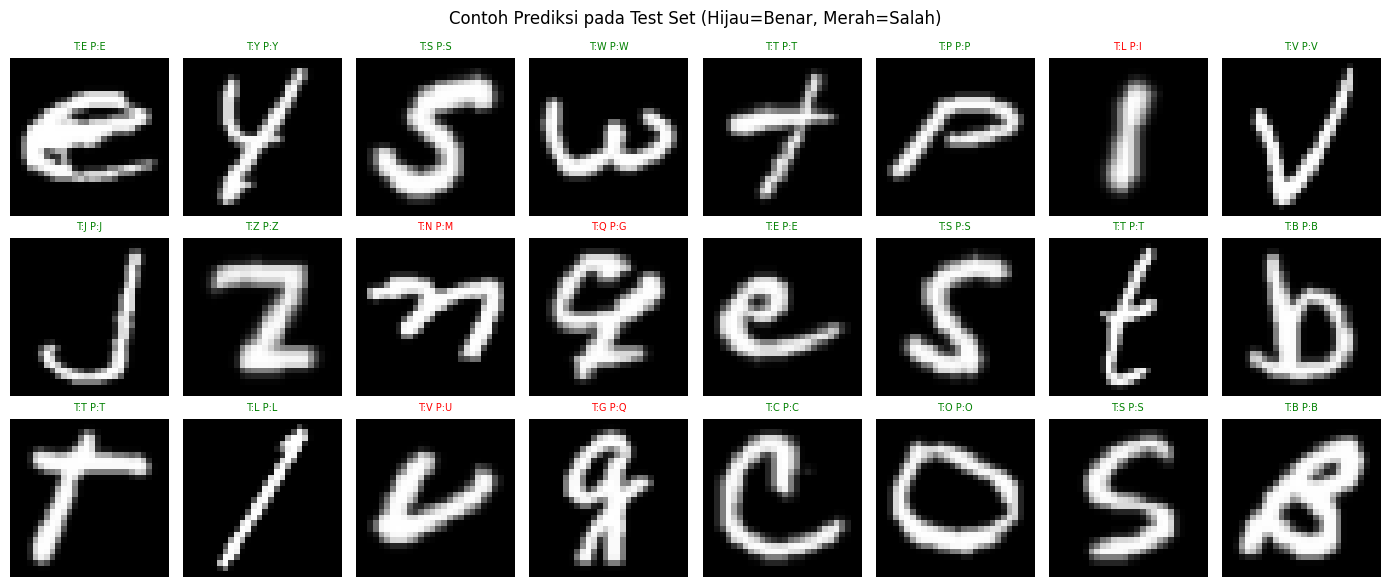

In [24]:
# ============================================================
# Visualisasi prediksi beberapa sampel test
# ============================================================
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
fig.suptitle('Contoh Prediksi pada Test Set (Hijau=Benar, Merah=Salah)', fontsize=12)

for i, ax in enumerate(axes.flat):
    if i < len(X_test):
        img = np.transpose(X_test[i].reshape(28, 28))
        ax.imshow(img, cmap='gray')
        true_lbl = letter_map[y_test[i]]
        pred_lbl = letter_map[y_test_pred[i]]
        color = 'green' if true_lbl == pred_lbl else 'red'
        ax.set_title(f'T:{true_lbl} P:{pred_lbl}', fontsize=7, color=color)
        ax.axis('off')

plt.tight_layout()
plt.savefig('predictions_sample.png', dpi=100)
plt.show()

In [25]:
# ============================================================
# Ringkasan Akhir
# ============================================================
print('=' * 55)
print('           RINGKASAN HASIL EKSPERIMEN')
print('=' * 55)
print(f'Dataset        : EMNIST Letters')
print(f'Total Samples  : 2600 (100/kelas x 26 kelas)')
print(f'Train/Test     : {X_train.shape[0]}/{X_test.shape[0]}')
print()
print(f'HOG Config:')
print(f'  orientations    = {HOG_PARAMS["orientations"]}')
print(f'  pixels_per_cell = {HOG_PARAMS["pixels_per_cell"]}')
print(f'  cells_per_block = {HOG_PARAMS["cells_per_block"]}')
print(f'  Feature length  = {X_train_hog.shape[1]}')
print()
print(f'Best SVM Params : {grid_search.best_params_}')
print()
print(f'Performance:')
print(f'  Train Accuracy : {train_acc*100:.2f}%')
print(f'  Test  Accuracy : {test_acc*100:.2f}%')
print(f'  Test  F1-Score : {test_f1:.4f}')
print('=' * 55)

           RINGKASAN HASIL EKSPERIMEN
Dataset        : EMNIST Letters
Total Samples  : 2600 (100/kelas x 26 kelas)
Train/Test     : 2080/520

HOG Config:
  orientations    = 12
  pixels_per_cell = (7, 7)
  cells_per_block = (2, 2)
  Feature length  = 432

Best SVM Params : {'C': 1, 'gamma': 'scale', 'kernel': 'poly'}

Performance:
  Train Accuracy : 99.57%
  Test  Accuracy : 84.04%
  Test  F1-Score : 0.8392
